## 1. Evaluate different ML models on the same subset of features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_censored, concordance_index_ipcw
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import joblib

In [2]:
print(plt.rcParams["font.family"])
plt.rcParams["font.sans-serif"] = ["Arial"] + plt.rcParams["font.sans-serif"]

['sans-serif']


In [3]:
# Load formatted cytokines data
df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")
df

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,globalhealthstatusql2,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs,ss
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,75.00,81.62,30.56,stage_I,no,no,alive,1839,alive,1
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,16.67,46.11,47.78,stage_IVA,no,yes,alive,1721,alive,4
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,50.00,57.56,45.68,stage_IVA,yes,no,death,48,death,4
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,0.00,19.23,94.44,stage_IVA,no,yes,death,131,death,3
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,75.00,76.67,17.44,stage_II,no,no,alive,1679,alive,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,76,S0076,UAB,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,...,NaN,NaN,NaN,stage_IVB,yes,yes,death,882,alive,3
208,77,S0077,UAB,18.86,91.86,71.49,22.67,5.42,146.71,18.96,...,NaN,NaN,NaN,stage_II,no,no,alive,1273,alive,1
209,78,S0078,UAB,12.99,66.46,51.61,9.46,2.89,28.61,2.28,...,NaN,NaN,NaN,stage_III,yes,yes,alive,1250,alive,4
210,79,S0079,UAB,13.66,75.02,40.79,8.96,3.81,38.38,5.04,...,NaN,NaN,NaN,stage_II,no,no,alive,1183,alive,2


In [4]:
# Encode survival status as binary variable
df["survival_status_encoded"] = df["survival_status"].map({"alive": 0, "death": 1})

In [5]:
# Map string labels to boolean: True = death observed, False = alive
event_observed = df["survival_status"].map(
    {"death": True, "alive": False}
)

# Check for NA values in survival_status mapping
assert event_observed.isna().sum() == 0, (
    f"Unmapped survival_status values found: "
    f"{df['survival_status'][event_observed.isna()].unique()}"
)

# Create structured array for survival analysis
y = Surv.from_arrays(
        event=event_observed,
        time=df["sx_to_lastfu"]
    )

y

array([(False, 1839.), (False, 1721.), ( True,   48.), ( True,  131.),
       (False, 1679.), ( True,  318.), ( True,  278.), (False, 1765.),
       (False, 1758.), ( True,  997.), ( True,  482.), ( True,  592.),
       (False, 1625.), (False, 1592.), (False, 1406.), ( True,   84.),
       ( True,  253.), ( True,   51.), (False, 1582.), (False, 1510.),
       (False, 1500.), (False, 1485.), (False, 1410.), (False, 1475.),
       ( True,  689.), ( True, 1055.), ( True,  433.), (False,  634.),
       ( True,  665.), (False, 1268.), ( True,  330.), (False, 1274.),
       (False, 1282.), (False,  765.), (False, 1123.), (False, 1094.),
       ( True,  618.), ( True,  490.), (False, 1137.), (False, 1095.),
       (False, 1050.), ( True,  494.), ( True,  597.), (False, 1085.),
       ( True,  379.), ( True,  355.), (False, 1078.), ( True,  385.),
       ( True,   87.), ( True,  763.), (False,  907.), (False,  814.),
       (False, 1018.), (False, 1014.), (False,  945.), (False,  631.),
      

In [6]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [7]:
# Subset cytokines and cohort columns for analysis
cytokines_df = df.loc[:, cytokines + ["cohort", "ss", "survival_status_encoded"]].drop(columns=["tgfalpha", "hbegf"])
cytokines_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,cohort,ss,survival_status_encoded
0,29.45,25.24,90.00,6.40,3.95,4.21,3.54,4.14,3.92,25.93,18.74,10.46,381.47,263.05,LLU,1,0
1,71.50,9.93,46.35,0.00,0.00,2.33,3.42,4.53,75.20,2.90,25.54,3.74,923.75,237.53,LLU,4,0
2,54.54,18.38,54.01,46.49,18.90,1.37,4.15,3.57,98.33,25.05,22.39,4.83,490.19,130.47,LLU,4,1
3,132.67,27.47,81.82,6.89,3.95,4.56,9.69,7.29,20.63,20.32,28.18,9.32,1148.22,34.22,LLU,3,1
4,28.01,13.63,66.20,5.44,0.92,3.04,2.42,5.44,10.63,17.14,39.61,5.94,1113.45,142.55,LLU,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,208.34,168.84,18.23,19.66,855.53,289.94,91.56,UAB,3,1
208,18.86,91.86,71.49,22.67,5.42,146.71,18.96,12.67,82.12,10.90,26.21,19.05,234.20,65.32,UAB,1,0
209,12.99,66.46,51.61,9.46,2.89,28.61,2.28,8.89,7.41,9.54,13.77,7.24,144.61,55.09,UAB,4,0
210,13.66,75.02,40.79,8.96,3.81,38.38,5.04,4.50,12.45,6.71,16.65,11.06,158.81,21.47,UAB,2,0


In [8]:
# Specify numeric features for survival ML models
numeric_features = cytokines_df.columns.drop(["cohort", "survival_status_encoded"])

In [9]:
# Subset model
selected_features = numeric_features.intersection(["il6", "il8", "il10", "tnfalpha", "ss"])
print(f"Selected features for ML model: {selected_features}")

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    cytokines_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y["event"],
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Selected features for ML model: Index(['il6', 'il8', 'il10', 'tnfalpha', 'ss'], dtype='object')
Training set size: 169 samples
Test set size: 43 samples


In [10]:
# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

In [11]:
X_train

,il6,il8,il10,tnfalpha,ss,cohort
37,11.83,6.00,49.43,13.39,4,LLU
100,12.62,13.33,52.00,20.12,5,LLU
145,2.19,5.05,12.59,9.44,3,UAB
174,5.22,10.10,11.90,11.67,4,UAB
10,19.03,10.88,7.26,9.47,4,LLU
...,...,...,...,...,...,...
79,6.10,4.09,19.13,22.13,4,LLU
53,8.34,11.47,612.56,8.76,4,LLU
108,13.17,6.48,6.66,34.28,6,LLU
107,15.13,6.19,19.13,50.30,5,LLU


In [12]:
X_train_transformed

,il6,il8,il10,tnfalpha,ss
37,0.256070,0.241921,-0.054554,-0.456563,0.680232
100,0.320005,1.882327,-0.031440,0.138915,1.375923
145,-0.451610,-0.488992,-0.417580,-0.768502,0.376605
174,-0.364485,-0.349853,-0.440358,-0.460468,1.139472
10,0.838763,1.334033,-0.433819,-0.803409,0.680232
...,...,...,...,...,...
79,-0.207656,-0.185525,-0.327063,0.316762,0.680232
53,-0.026374,1.466071,5.010077,-0.866230,0.680232
108,0.364516,0.349342,-0.439215,1.391808,2.071615
107,0.523138,0.284442,-0.327063,2.809276,1.375923


In [13]:
# Sanity check: Ensure that the time range of the test data is within the time range of the training data
y_events = y_train[y_train["event"]]
train_min, train_max = y_events["time"].min(), y_events["time"].max()

y_events = y_test[y_test["event"]]
test_min, test_max = y_events["time"].min(), y_events["time"].max()

assert (
    train_min <= test_min < test_max < train_max
), "time range or test data is not within time range of training data."

In [14]:
# Evaluation times for time-dependent ROC (restricted to 2 years)
horizon_days = 365.24 * 2

# last time must be strictly below max follow-up
upper_time = min(
    horizon_days,
    np.nextafter(y_train["time"].max(), -np.inf),
    np.nextafter(y_test["time"].max(), -np.inf),
)

# use event-time quantiles from test set, then keep valid range
event_times_test = y_test["time"][y_test["event"]]
times = np.percentile(event_times_test, np.linspace(5, 95, 15))
times = np.unique(times[(times >= y_test["time"].min()) & (times <= upper_time)])

print(times)
print(f"Max evaluation time: {times.max():.1f} days (<= 2 years)")

[ 77.1 144.  220.  258.8 263.  269.8 297.9 306.  331.2 540.4 594.1 596.2
 631.  704.2]
Max evaluation time: 704.2 days (<= 2 years)


il6: mean AUC = 0.610
il8: mean AUC = 0.591
il10: mean AUC = 0.628
tnfalpha: mean AUC = 0.693
ss: mean AUC = 0.739


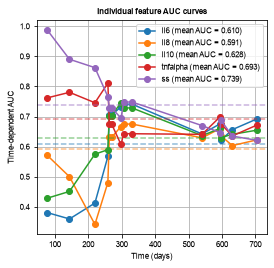

In [15]:
# Plot time-dependent AUC curves for individual features separately
plt.figure(figsize=(10.5, 10, "cm"))

X_test_arr = np.asarray(X_test_transformed)

for i, col in enumerate(selected_features):
    auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, X_test_arr[:, i], times)
    print(f"{col}: mean AUC = {mean_auc:.3f}")
    plt.plot(times, auc, marker="o", label=f"{col} (mean AUC = {mean_auc:.3f})")
    plt.axhline(mean_auc, linestyle="--", alpha=0.5, color=plt.gca().lines[-1].get_color())

plt.xlabel("Time (days)", fontsize=8)
plt.xticks(fontsize=8)
plt.ylabel("Time-dependent AUC", fontsize=8)
plt.yticks(fontsize=8)
plt.title("Individual feature AUC curves", fontsize=8, fontweight="bold")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)

# plt.savefig("../figures/individual_feature_auc_curves.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [16]:
# CoxPH surival model
cph = CoxPHSurvivalAnalysis()
cph.fit(X_train_transformed, y_train)
c_index = cph.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

cph_risk_scores = cph.predict(X_test_transformed)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(y_train, y_test, cph_risk_scores, times)
print(f"Mean AUC: {cph_mean_auc:.3f}")

C-index: 0.722
Mean AUC: 0.798


In [17]:
# Gradient-boosted CoxPH loss with regression trees as base learner
gbsa_tree = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=2026)
gbsa_tree.fit(X_train_transformed, y_train)
c_index = gbsa_tree.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

gbsa_tree_risk_scores = gbsa_tree.predict(X_test_transformed)
gbsa_tree_auc, gbsa_tree_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_tree_risk_scores, times)
print(f"Mean AUC: {gbsa_tree_mean_auc:.3f}")

C-index: 0.702
Mean AUC: 0.755


In [18]:
# Gradient boosting CoxPH with component-wise least squares as base learner
gbsa_ls = ComponentwiseGradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, random_state=2026)
gbsa_ls.fit(X_train_transformed, y_train)
cindex = gbsa_ls.score(X_test_transformed, y_test)
print(f"C-index: {round(cindex, 3)}")

gbsa_ls_risk_scores = gbsa_ls.predict(X_test_transformed)
gbsa_ls_auc, gbsa_ls_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_ls_risk_scores, times)
print(f"Mean AUC: {gbsa_ls_mean_auc:.3f}")

C-index: 0.722
Mean AUC: 0.798


In [19]:
# Random Survival Forest (RSF) model
rsf = RandomSurvivalForest(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=30,
    min_samples_split=2,
    max_features="sqrt",
    random_state=2026)
rsf.fit(X_train_transformed, y_train)
c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

C-index: 0.741
Mean AUC: 0.808


In [20]:
# Permutation-based feature importance
result = permutation_importance(rsf, X_test_transformed, y_test, n_repeats=15, random_state=2026)

pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test_transformed.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
ss,0.158505,0.064224
tnfalpha,0.040398,0.030661
il10,-0.004047,0.012797
il6,-0.008093,0.015278
il8,-0.013580,0.015023


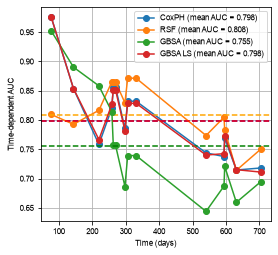

In [21]:
# Plot all models together for comparison
plt.figure(figsize=(10.5, 10, "cm"))

plt.plot(times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
plt.axhline(cph_mean_auc, color="blue", linestyle="--",)
plt.plot(times, rsf_auc, "o-", label=f"RSF (mean AUC = {rsf_mean_auc:.3f})")
plt.axhline(rsf_mean_auc, color="orange", linestyle="--",)
plt.plot(times, gbsa_tree_auc, "o-", label=f"GBSA (mean AUC = {gbsa_tree_mean_auc:.3f})")
plt.axhline(gbsa_tree_mean_auc, color="green", linestyle="--",)
plt.plot(times, gbsa_ls_auc, "o-", label=f"GBSA LS (mean AUC = {gbsa_ls_mean_auc:.3f})")
plt.axhline(gbsa_ls_mean_auc, color="red", linestyle="--",)
plt.xlabel("Time (days)", fontsize=8)
plt.xticks(fontsize=8)
plt.ylabel("Time-dependent AUC", fontsize=8)
plt.yticks(fontsize=8)
# plt.title("Time-dependent AUC by subset model", fontsize=8, fontweight="bold")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)

# plt.savefig("../figures/time_dependent_auc_subset_model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Evaluate the RSF model on different subsets of features

In [22]:
# Define a function to run RSF on a given feature set
def run_rsf(feature_set, cols, cytokines_df, numeric_features, y, times,
            cohort_col="cohort", test_size=0.2):
    """Train/evaluate an RSF model on one feature subset. Returns a dict
    with the model, C-index, AUC curve, and mean AUC."""
    
    selected_features = numeric_features.intersection(cols).tolist()
    feature_cols = selected_features + [cohort_col]

    X_train, X_test, y_train, y_test = train_test_split(
        cytokines_df[feature_cols], y,
        test_size=test_size, random_state=2024, stratify=y["event"]
    )
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")

    # Preprocessing
    # Fit one scaler per cohort on the training set, store them explicitly
    cohort_scalers = {}
    for cohort, group in X_train.groupby("cohort"):
        sc = StandardScaler()
        sc.fit(group[selected_features])
        cohort_scalers[cohort] = sc
    
    def apply_cohort_scaling(X, scalers, feature_cols):
        parts = []
        for cohort, group in X.groupby("cohort"):
            transformed = scalers[cohort].transform(group[feature_cols])
            parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
        return pd.concat(parts).loc[X.index]
    
    X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
    X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

    # # Random Survival Forest (RSF) model
    rsf = RandomSurvivalForest(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=30,
        min_samples_split=2,
        max_features="sqrt",
        random_state=2026
    )
    rsf.fit(X_train_transformed, y_train)
    c_index = rsf.score(X_test_transformed, y_test)
    rsf_risk_scores = rsf.predict(X_test_transformed)
    rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)

    print(f"[{feature_set}] features: {selected_features}")
    print(f"[{feature_set}] C-index: {c_index:.3f} | Mean AUC: {rsf_mean_auc:.3f}")

    return {
        "feature_set": feature_set,
        "features": selected_features,
        "model": rsf,
        "c_index": c_index,
        "auc": rsf_auc,
        "mean_auc": rsf_mean_auc
    }

In [33]:
# Define a function to run RSF on all feature sets and plot AUC curves
def run_all(feature_sets, cytokines_df, numeric_features, y, times, data_dir, fig_dir, color_map=None,**kwargs):
    """Run `run_rsf` for every {feature_set: cols} pair. Returns (results, summary_df)
    and plots all AUC curves together on one figure."""

    results = [
        run_rsf(feature_set, cols, cytokines_df, numeric_features, y, times, **kwargs)
        for feature_set, cols in feature_sets.items()
    ]

    summary_df = pd.DataFrame([
        {
            "feature_set": res["feature_set"], 
            "n_features": len(res["features"]),
            "features": ", ".join(res["features"]),
            "c_index": round(res["c_index"], 3),
            "mean_auc": round(res["mean_auc"], 3)
        }
        for res in results
    ]).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    summary_df.to_csv(f"{data_dir}/rsf-feature-sets_pooled-llu-uab-summary.csv", index=False)

    # Sort results by mean_auc descending for legend ordering
    results_sorted = sorted(results, key=lambda x: x["mean_auc"], reverse=True)
    
    plt.figure(figsize=(3.75, 8.5/2, "in"), dpi=300)
    for res in results_sorted:
        set_name = res["feature_set"]
        line_color = color_map.get(set_name) if color_map else None

        line, = plt.plot(
            times,
            res["auc"],
            marker="o",
            linestyle="-",
            color=line_color,
            label=f'{", ".join(res["features"])} (mean AUC = {res["mean_auc"]:.3f})',
        )
        plt.axhline(
            res["mean_auc"],
            color=line.get_color(),
            linestyle="--",
        )
    plt.xlabel("Time (days)", fontsize=8)
    plt.xticks(fontsize=8)
    plt.ylabel("Time-dependent AUC", fontsize=8)
    plt.yticks(fontsize=8)
    plt.title("Pooled LLU and UAB cohorts with 20% hold out", fontsize=8, fontweight="bold")
    plt.legend(loc="upper center", fontsize=8, bbox_to_anchor=(0.5, -0.15))
    plt.grid(True)
    
    plt.savefig(f"{fig_dir}/time-dependent-auc_rsf-feature-comparisons_pooled-llu-uab_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
    
    plt.show()
    
    return results, summary_df

In [34]:
# Specify feature sets for RSF model evaluation
feature_sets = {
    "set_01": ["ss"],
    "set_02": ["ss", "il6", "il8", "il10", "tnfalpha"],
    "set_03": ["ss", "il6", "il10", "tnfalpha"],
    "set_04": ["ss", "il8", "il10", "tnfalpha"],
    "set_05": ["ss", "il10", "tnfalpha"],
}

feature_set_colors = {
    "set_01": "#E64B35FF",
    "set_02": "#4DBBD5FF",
    "set_03": "#00A087FF",
    "set_04": "#3C5488FF",
    "set_05": "#F39B7FFF",
}

Training set size: 169 samples
Test set size: 43 samples
[set_01] features: ['ss']
[set_01] C-index: 0.680 | Mean AUC: 0.754
Training set size: 169 samples
Test set size: 43 samples
[set_02] features: ['il6', 'il8', 'il10', 'tnfalpha', 'ss']
[set_02] C-index: 0.741 | Mean AUC: 0.808
Training set size: 169 samples
Test set size: 43 samples
[set_03] features: ['il6', 'il10', 'tnfalpha', 'ss']
[set_03] C-index: 0.754 | Mean AUC: 0.845
Training set size: 169 samples
Test set size: 43 samples
[set_04] features: ['il8', 'il10', 'tnfalpha', 'ss']
[set_04] C-index: 0.729 | Mean AUC: 0.790
Training set size: 169 samples
Test set size: 43 samples
[set_05] features: ['il10', 'tnfalpha', 'ss']
[set_05] C-index: 0.766 | Mean AUC: 0.853


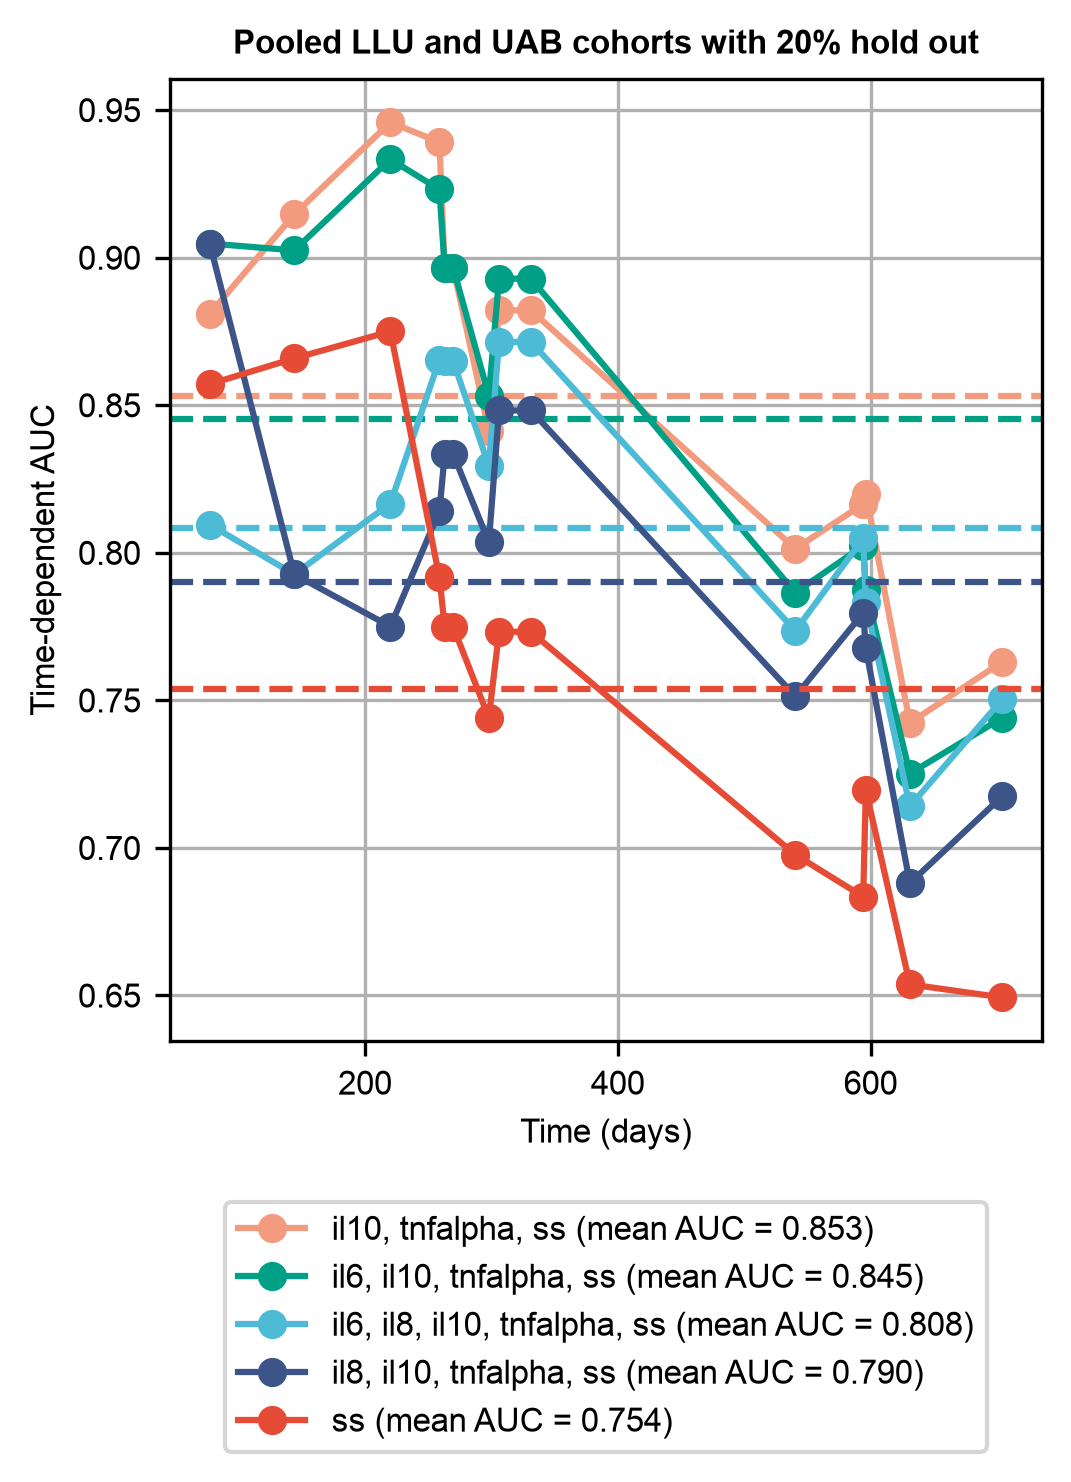

,feature_set,n_features,features,c_index,mean_auc
0,set_05,3,"il10, tnfalpha, ss",0.766,0.853
1,set_03,4,"il6, il10, tnfalpha, ss",0.754,0.845
2,set_02,5,"il6, il8, il10, tnfalpha, ss",0.741,0.808
3,set_04,4,"il8, il10, tnfalpha, ss",0.729,0.790
4,set_01,1,ss,0.680,0.754


In [35]:
results, summary_df = run_all(
    feature_sets, cytokines_df, numeric_features, y, times,
    color_map=feature_set_colors,
    data_dir="../data_processed", fig_dir="../figures"
)
summary_df

## 3. Hyperparameter tuning of the RSF model on the best subset of features

In [46]:
# Best subset of features for RSF model
selected_features = numeric_features.intersection(feature_sets["set_06"])
print(f"Selected features for ML model: {selected_features}")

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    cytokines_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y["event"],
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

# Random Survival Forest (RSF) model
rsf = RandomSurvivalForest(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=30,
    min_samples_split=2,
    max_features="sqrt",
    random_state=2026
)
rsf.fit(X_train_transformed, y_train)

c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

Selected features for ML model: Index(['il10', 'tnfalpha', 'ss'], dtype='object')
Training set size: 169 samples
Test set size: 43 samples
C-index: 0.766
Mean AUC: 0.853


RSF params:
- n_estimators: 200
- max_depth: None
- min_samples_leaf: 30
- min_samples_split: 2
- max_features: "sqrt"
- the rests are default values

In [48]:
# Save the RSF model and related artifacts for future use
artifact = {
    "model": rsf,
    "cohort_scalers": cohort_scalers,
    "selected_features": list(selected_features),
    "X_train": X_train_transformed,
    "X_test": X_test_transformed,
    "y_train": y_train,
    "y_test": y_test,
    "times": times,
    "c_index": c_index,
    "mean_auc": rsf_mean_auc,
    "sksurv_version": __import__("sksurv").__version__,
    "sklearn_version": __import__("sklearn").__version__,
}

joblib.dump(artifact, "../data_processed/rsf_bundle.joblib")

['../data_processed/rsf_bundle.joblib']